In [3]:
# 1. Libraries
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 2. CSV를 Parquet으로 변환 (메모리 효율화)
#csv_dir = "./data/raw"
#parquet_dir = "./data/processed"

csv_dir = "/content/drive/MyDrive/web_F"
parquet_dir = "/content/drive/MyDrive/open_web_F_parquet"

file_mapping = {
    'train.csv': 'train.parquet',
    'test.csv': 'test.parquet',
    'sample_submission.csv': 'submission.parquet'
}

for csv_name, parquet_name in file_mapping.items():
    df = pd.read_csv(f"{csv_dir}/{csv_name}", low_memory=False)
    df.to_parquet(
        f"{parquet_dir}/{parquet_name}",
        compression='snappy',
        index=False
    )
    print(f"{csv_name}: {df.shape}")
    del df

# 3. Parquet 파일 로딩
train = pd.read_parquet(f"{parquet_dir}/train.parquet")
test = pd.read_parquet(f"{parquet_dir}/test.parquet")

train.csv: (28605391, 41)
test.csv: (4538541, 40)
sample_submission.csv: (4538541, 2)


In [7]:
# Pandas 출력 옵션 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 피처요약표
def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary = summary.rename(columns={'index': 'Feature'})
    summary['결측값 개수'] = df.isnull().sum().values
    summary['고유값 개수'] = df.nunique().values
    summary['첫 번째 값'] = df.loc[0].values
    summary['두 번째 값'] = df.loc[1].values
    summary['세 번째 값'] = df.loc[2].values
    return summary

print("="*60)
print("📊 피처 요약표")
print("="*60)
resumetable(train)

📊 피처 요약표
Dataset Shape: (28605391, 41)


,Feature,dtypes,결측값 개수,고유값 개수,첫 번째 값,두 번째 값,세 번째 값
0,ID,object,0,28605391,TRAIN_00000000,TRAIN_00000001,TRAIN_00000002
1,Click,int64,0,2,1,0,0
2,F01,object,1234711,4760930,NSLHFNS,VGIVWZQ,JCDXFYU
3,F02,object,1234711,304404,AVKQTCL,LSUSMVO,PILDDJU
4,F03,object,10543986,63,DTZFPRW,PQGWFJZ,IAGJDOH
5,F04,float64,5742331,9978,114.0,26.0,119.0
6,F05,object,1234711,5343556,ISVXFVA,NFRVLWS,LFPUEOV
7,F06,int64,0,8562,1,43,0
8,F07,object,0,151200,PQZBVMG,IMPIGJT,FFUTIRZ
9,F08,object,0,79,LPYPUNA,MIGYEEG,OFKQGTY


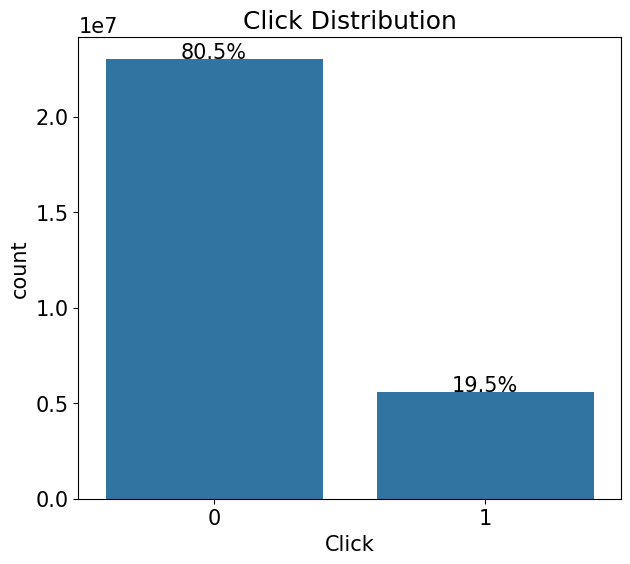

In [8]:
#시각화 라이브러리
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

def write_percent(ax, total_size):
    '''도형 객체를 순회하며 막대 그래프 상단에 타깃값 비율 표시'''
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size*100

        ax.text(left_coord + width/2.0,
                height + total_size*0.001,
                '{:1.1f}%'.format(percent),
                ha='center')

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rc('font', size=15)
plt.figure(figsize=(7, 6))
ax = sns.countplot(x='Click', data=train)
write_percent(ax, len(train))
plt.title('Click Distribution')
plt.show()

In [9]:
print(f"Initial memory:")
train_initial = train.memory_usage(deep=True).sum() / 1024**3
test_initial = test.memory_usage(deep=True).sum() / 1024**3
print(f"Train: {train_initial:.2f} GB")
print(f"Test: {test_initial:.2f} GB")

# 4. ID 제거
if 'ID' in train.columns:
    train = train.drop('ID', axis=1)
    test = test.drop('ID', axis=1)
    print(f"\nID column dropped (unnecessary for prediction)")

# 5. Category Conversion
def convert_to_category(df):
    """Object to Category conversion"""
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df

train = convert_to_category(train)
test = convert_to_category(test)

print(f"\nAfter category conversion:")
train_after_category = train.memory_usage(deep=True).sum() / 1024**3
test_after_category = test.memory_usage(deep=True).sum() / 1024**3
print(f"Train: {train_after_category:.2f} GB")
print(f"Test: {test_after_category:.2f} GB")

category_reduction_train = (1 - train_after_category/train_initial) * 100
category_reduction_test = (1 - test_after_category/test_initial) * 100
print(f"Reduction - Train: {category_reduction_train:.1f}%, Test: {category_reduction_test:.1f}%")

# 6. Downcasting
def downcast_dtypes(df):
    """Numeric downcasting"""
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

train = downcast_dtypes(train)
test = downcast_dtypes(test)

print(f"\nAfter downcasting:")
train_after_downcast = train.memory_usage(deep=True).sum() / 1024**3
test_after_downcast = test.memory_usage(deep=True).sum() / 1024**3
print(f"Train: {train_after_downcast:.2f} GB")
print(f"Test: {test_after_downcast:.2f} GB")

downcast_reduction_train = (1 - train_after_downcast/train_after_category) * 100
downcast_reduction_test = (1 - test_after_downcast/test_after_category) * 100
print(f"Reduction - Train: {downcast_reduction_train:.1f}%, Test: {downcast_reduction_test:.1f}%")

total_reduction_train = (1 - train_after_downcast/train_initial) * 100
total_reduction_test = (1 - test_after_downcast/test_initial) * 100
print(f"\nTotal reduction:")
print(f"Train: {train_initial:.2f} GB → {train_after_downcast:.2f} GB ({total_reduction_train:.1f}%)")
print(f"Test: {test_initial:.2f} GB → {test_after_downcast:.2f} GB ({total_reduction_test:.1f}%)")

# 7. Target Encoding
def kfold_target_encoding(train, test, cat_cols, target_col, n_splits=5, smoothing=10):
    """K-Fold Target Encoding with Smoothing"""
    global_mean = train[target_col].mean()
    train_encoded = pd.DataFrame(index=train.index)
    test_encoded = pd.DataFrame(index=test.index)

    for col in cat_cols:
        train_col_str = train[col].astype(str)
        test_col_str = test[col].astype(str)
        train_encoded[col] = np.nan

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(train):
            fold_train = pd.DataFrame({
                'cat': train_col_str.iloc[train_idx],
                'target': train[target_col].iloc[train_idx]
            })
            stats = fold_train.groupby('cat')['target'].agg(['mean', 'count'])
            smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
            smoothed_dict = smoothed.to_dict()

            val_categories = train_col_str.iloc[val_idx]
            encoded_values = val_categories.map(smoothed_dict).values
            train_encoded.iloc[val_idx, train_encoded.columns.get_loc(col)] = encoded_values

        full_train = pd.DataFrame({
            'cat': train_col_str,
            'target': train[target_col]
        })
        stats = full_train.groupby('cat')['target'].agg(['mean', 'count'])
        smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        smoothed_dict = smoothed.to_dict()

        test_encoded[col] = test_col_str.map(smoothed_dict).fillna(global_mean)

        train_encoded[col] = train_encoded[col].astype('float32')
        test_encoded[col] = test_encoded[col].astype('float32')

    return train_encoded, test_encoded

cat_cols = [col for col in train.select_dtypes(include=['category']).columns
            if col != 'Click']

train_te, test_te = kfold_target_encoding(train, test, cat_cols, 'Click', n_splits=5, smoothing=10)

train_final = train.drop(columns=cat_cols).join(train_te)
test_final = test.drop(columns=cat_cols).join(test_te)

Initial memory:
Train: 41.97 GB
Test: 6.63 GB

ID column dropped (unnecessary for prediction)

After category conversion:
Train: 6.09 GB
Test: 1.05 GB
Reduction - Train: 85.5%, Test: 84.2%

After downcasting:
Train: 4.47 GB
Test: 0.81 GB
Reduction - Train: 26.7%, Test: 22.6%

Total reduction:
Train: 41.97 GB → 4.47 GB (89.4%)
Test: 6.63 GB → 0.81 GB (87.8%)


In [16]:
print('train_final')
print(train_final.dtypes.value_counts())
print('\ntest_final')
print(test_final.dtypes.value_counts())

train_final
float32    37
int8        1
int32       1
int16       1
Name: count, dtype: int64

test_final
float32    37
int16       2
Name: count, dtype: int64


In [18]:
import pickle

# 저장 경로 설정
save_dir = "/content/drive/MyDrive/open_web_F_parquet/preprocessed"
#save_dir = "./data/processed"
os.makedirs(save_dir, exist_ok=True)

train_final.to_parquet(
    f"{save_dir}/train_preprocessed.parquet",
    engine='pyarrow',
    compression='snappy',
    index=False
)

test_final.to_parquet(
    f"{save_dir}/test_preprocessed.parquet",
    engine='pyarrow',
    compression='snappy',
    index=False
)

print(f"저장 완료:")

저장 완료:
